In [1]:
# Environment Check - Run this cell to verify Python environment
import sys
import os

print("🔍 Current Environment:")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"Working directory: {os.getcwd()}")

# Check if we're using the UV environment
expected_path = "/media/ubuntu/winD/PK/project/Diffusion/KAIST_2024/.venv/bin/python"
if sys.executable == expected_path:
    print("✅ SUCCESS: Using UV environment!")
else:
    print("❌ ISSUE: Not using UV environment")
    print(f"Expected: {expected_path}")
    print(f"Current:  {sys.executable}")
    print("\n📝 Try these steps:")
    print("1. Click kernel selector (top-right)")
    print("2. Look for 'Diffusion UV' or 'KAIST UV Environment'")
    print("3. Or try Command Palette: Ctrl+Shift+P > 'Notebook: Select Kernel'")

print(f"\nVirtual environment: {sys.prefix}")

🔍 Current Environment:
Python executable: /media/ubuntu/winD/PK/project/Diffusion/KAIST_2024/.venv/bin/python
Python version: 3.9.23 (main, Jun  5 2025, 13:40:20) 
[GCC 11.2.0]
Working directory: /media/ubuntu/winD/PK/project/Diffusion/KAIST_2024/Diffusion-Assignment3-ControlNet-LoRA-master/task_1_controlnet
✅ SUCCESS: Using UV environment!

Virtual environment: /media/ubuntu/winD/PK/project/Diffusion/KAIST_2024/.venv


In [2]:
import os
from PIL import Image
import torch

from diffusion.controlnet import ControlNetModel
from diffusion.pipeline_controlnet import StableDiffusionControlNetPipeline
from diffusers import UniPCMultistepScheduler
from diffusers.utils import load_image

device = "cuda:0"

### Set model paths

import torch
from diffusers import StableDiffusionPipeline

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda"


pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  
    
image.save("astronaut_rides_horse.png")

In [2]:
base_model_path = "runwayml/stable-diffusion-v1-5"      # NOTE: set as the base Stable Diffusion model
controlnet_path = "./runs/controlnet_fill50k"           # NOTE: set as the output directory of your ControlNet training

### Load models and scheduler

In [3]:
# Load ControlNet
controlnet = ControlNetModel.from_pretrained(
    controlnet_path, 
    torch_dtype=torch.float16
)
# Load Stable Diffusion with ControlNet
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    base_model_path, 
    controlnet=controlnet, 
    torch_dtype=torch.float16,
    safety_checker=None,
)
# Set scheduler
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# Load model to GPU
pipe.to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/media/ubuntu/Data/tools/anaconda3/envs/py+llm/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusion.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look 

StableDiffusionControlNetPipeline {
  "_class_name": "StableDiffusionControlNetPipeline",
  "_diffusers_version": "0.28.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "controlnet": [
    "diffusion.controlnet",
    "ControlNetModel"
  ],
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "UniPCMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

### Load condition for ControlNet

Prompt: pale golden rod circle with old lace background


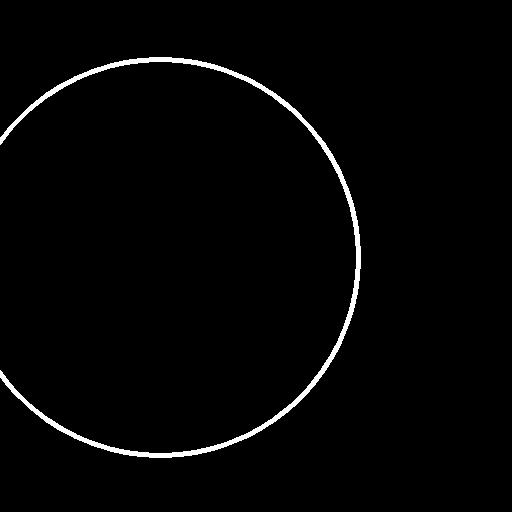

In [4]:
control_image = load_image("./data/conditioning_image_1.png")
prompt = "pale golden rod circle with old lace background"

print(f"Prompt: {prompt}")
control_image

  0%|          | 0/20 [00:00<?, ?it/s]

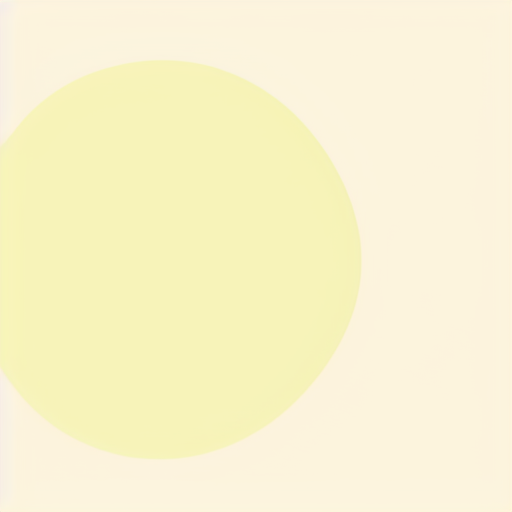

In [5]:
seed = 10
generator = torch.manual_seed(seed)

# Generate image
image = pipe(
    prompt, 
    num_inference_steps=20, 
    generator=generator, 
    image=control_image
).images[0]

image
# image.save("./output.png")

In [15]:
import json

def load_test_prompts(json_path):
    with open(json_path, "r") as f:
        prompts = json.load(f)
    return prompts

In [23]:
seed = 10
generator = torch.manual_seed(seed)

prompts_dict = load_test_prompts("./data/test_prompts.json")

for i in range(len(prompts_dict)):
    prompt = prompts_dict[str(i)]
    control_image_1 = load_image(f"./data/conditioning_image_1.png")
    control_image_2 = load_image(f"./data/conditioning_image_2.png")

    print(f"Prompt: {prompt}")
    # Generate image
    image = pipe(
        prompt, 
        num_inference_steps=20, 
        generator=generator, 
        image=control_image_1
    ).images[0]
    image.save(f"./gen/output_1_{i}.png")


    print(f"Prompt: {prompt}")
    # Generate image
    image = pipe(
        prompt, 
        num_inference_steps=20, 
        generator=generator, 
        image=control_image_2
    ).images[0]

    image.save(f"./gen/output_2_{i}.png")


Prompt: pale golden rod circle with old lace background


  0%|          | 0/20 [00:00<?, ?it/s]

Prompt: pale golden rod circle with old lace background


  0%|          | 0/20 [00:00<?, ?it/s]

Prompt: sea green circle with a light cyan background


...

  0%|          | 0/20 [00:00<?, ?it/s]

Prompt: forest green circle with an antique brown background


  0%|          | 0/20 [00:00<?, ?it/s]

Prompt: forest green circle with an antique brown background


  0%|          | 0/20 [00:00<?, ?it/s]